# Proyecto RappiPlus: de datos a decisiones de negocio

**Introducción**


El objetivo de este proyecto es evaluar el desempeño del servicio **RappiPlus** para apoyar **decisiones de negocio basadas en datos**.

Se trabajan con múltiples datasets del negocio:

- **rappiplus_orders_raw.csv** → información de pedidos, precios, descuentos y revenue  
- **rappiplus_catalog.csv** → costos de productos, categorías y proveedores  
- **rappiplus_marketing_spend.csv** → inversión en marketing por canal y país  
- **events / users / user_activity (SQL)** → comportamiento del usuario dentro de la plataforma  
- **experiment_checkout_ui.csv** → resultados de un experimento A/B en el checkout  

El análisis sigue una lógica clara y progresiva:

1. 🔍 Evaluar si podemos confiar en los datos (calidad de datos en Python)

2. 💰 Analizar si el negocio es rentable (revenue, costos y profit)  

3. 🛒 Entender dónde se pierden los usuarios (funnel de conversión)  

4. 🔁 Evaluar si los usuarios regresan (retención por cohortes)  

5. 🧪 Validar si los cambios generan impacto (test estadístico)  

6. 📊 Comunicar los resultados (dashboard en BI)  

A lo largo del proyecto, se transforman datos en insights para responder preguntas clave del negocio y proponer **recomendaciones accionables**.

---

## 🔹 Paso 1: Cargar y validar la calidad de los datos

---

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:** cargar y explorar las fuentes de datos utilizadas en el análisis para evaluar su estructura, calidad y consistencia antes de realizar las transformaciones.

---

In [ ]:
# importar librerías
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.proportion import proportions_ztest

In [ ]:
# cargar archivos
orders = pd.read_csv('https://practicum-content.s3.amazonaws.com/datasets/rappiplus_orders_raw.csv')
catalog = pd.read_csv('https://practicum-content.s3.amazonaws.com/datasets/rappiplus_catalog.csv')
marketing = pd.read_csv('https://practicum-content.s3.amazonaws.com/datasets/rappiplus_marketing_spend.csv')

In [ ]:
# explorar datasets
orders.head()

,id_pedido,id_usuario,fecha_hora_pedido,pais,dispositivo,fuente_referencia,nombre_producto,categoria_producto,cantidad,precio_unitario,monto_descuento,monto_total
0,order_0,user_6993,2025-05-22,Argentina,desktop,organic,Jacket-Winter-M,Moda,2.0,332.69,0.0,665.37
1,order_1,user_1329,2025-06-15,Mexico,desktop,paid_search,Tablet-Standard-64GB,Electronica,1.0,176.86,5.0,171.86
2,order_2,user_3194,2025-05-02,Argentina,desktop,social,Blender-XL-Red,Hogar,2.0,102.99,10.0,195.99
3,order_3,user_4510,2025-06-09,Colombia,mobile,social,Tablet-Standard-64GB,Electronica,1.0,257.87,15.0,242.87
4,order_4,user_5044,2025-03-30,Argentina,desktop,paid_search,Blender-XL-Red,Hogar,1.0,336.28,0.0,336.28


In [ ]:
catalog.head()

,nombre_producto,categoria_producto,costo_unitario,proveedor
0,Laptop-Gaming-16GB,Electrónica,280.68,"Fuller, Pena and Myers"
1,Phone-Pro-128GB,Electrónica,10.12,King Ltd
2,Tablet-Standard-64GB,Electrónica,25.21,Bowers LLC
3,Blender-XL-Red,Hogar,176.64,Long-Reid
4,Vacuum-Pro-Black,Hogar,16.60,"Rivera, Carr and Finley"


In [ ]:
marketing.head()

,fecha,pais,id_campaña,canal,gasto
0,2025-01-01,Mexico,organic_Mexico,organic,2446.25
1,2025-01-01,Mexico,paid_search_Mexico,paid_search,2704.34
2,2025-01-01,Mexico,social_Mexico,social,2045.01
3,2025-01-01,Colombia,organic_Colombia,organic,2597.21
4,2025-01-01,Colombia,paid_search_Colombia,paid_search,1771.40


---

### Revisión y calidad de datos

**🎯 Objetivo:** Detectar y corregir problemas en los datos que puedan afectar el análisis de revenue, costos y rentabilidad.

Se revisan los 3 datasets
- Validar y convertir fechas al formato correcto  
- Revisar variables numéricas (sin negativos o ceros inválidos)  
- Verificar consistencia de montos  
- Eliminar duplicados  
- Revisar variables categóricas
---

# Revisión y limpieza tabla orders

In [ ]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25100 entries, 0 to 25099
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id_pedido           25100 non-null  object 
 1   id_usuario          25100 non-null  object 
 2   fecha_hora_pedido   25100 non-null  object 
 3   pais                24800 non-null  object 
 4   dispositivo         25080 non-null  object 
 5   fuente_referencia   25070 non-null  object 
 6   nombre_producto     25070 non-null  object 
 7   categoria_producto  25020 non-null  object 
 8   cantidad            25050 non-null  float64
 9   precio_unitario     25050 non-null  float64
 10  monto_descuento     25050 non-null  float64
 11  monto_total         25100 non-null  float64
dtypes: float64(4), object(8)
memory usage: 2.3+ MB


In [ ]:
# Conversión fecha a formato correcto
orders['fecha_hora_pedido'] = pd.to_datetime(orders['fecha_hora_pedido'],errors='coerce')

In [ ]:
# Validación de existencia de nulos
orders['fecha_hora_pedido'].isna().sum()

0

In [ ]:
# Valores nulos en el dataset
orders.isnull().sum()

id_pedido               0
id_usuario              0
fecha_hora_pedido       0
pais                  300
dispositivo            20
fuente_referencia      30
nombre_producto        30
categoria_producto     80
cantidad               50
precio_unitario        50
monto_descuento        50
monto_total             0
dtype: int64

In [ ]:
# Revisión variables numericas
orders[['cantidad','precio_unitario','monto_descuento','monto_total']].describe()

,cantidad,precio_unitario,monto_descuento,monto_total
count,25050.000000,25050.000000,25050.000000,2.510000e+04
mean,7.092735,259.305549,4.500798,2.072680e+03
std,296.277003,138.726461,5.223010,9.894995e+04
min,-2.000000,20.030000,0.000000,-4.926500e+02
25%,1.000000,138.377500,0.000000,1.805075e+02
50%,2.000000,258.715000,0.000000,3.417500e+02
75%,2.000000,380.332500,10.000000,5.185800e+02
max,20000.000000,499.960000,15.000000,8.840200e+06


In [ ]:
# Eliminar cantidades y montos negativos
orders = orders[(orders['cantidad'] >= 0) &(orders['monto_total'] >= 0)]

In [ ]:
# Validación de los cambios
print("Cantidad negativa:", (orders['cantidad'] < 0).sum())
print("Monto negativo:", (orders['monto_total'] < 0).sum())
print("Filas totales:", len(orders))

Cantidad negativa: 0
Monto negativo: 0
Filas totales: 25046


In [ ]:
orders['cantidad'].quantile(0.99)

2.0

In [ ]:
# Eliminar outliers
orders = orders[orders['cantidad'] <= 2]

In [ ]:
# Validación de los cambios
orders[orders['cantidad']>=10000]

,id_pedido,id_usuario,fecha_hora_pedido,pais,dispositivo,fuente_referencia,nombre_producto,categoria_producto,cantidad,precio_unitario,monto_descuento,monto_total


In [ ]:
orders[['cantidad','monto_total']].describe()

,cantidad,monto_total
count,25036.000000,25036.000000
mean,1.504953,385.807512
std,0.499985,255.750599
min,1.000000,5.240000
25%,1.000000,180.330000
50%,2.000000,341.360000
75%,2.000000,517.640000
max,2.000000,999.890000


In [ ]:
# ver duplicados
print("Duplicados completos:", orders.duplicated().sum())

print("IDs duplicados:", orders['id_pedido'].duplicated().sum())

Duplicados completos: 100
IDs duplicados: 100


In [ ]:
# eliminar duplicados
orders = orders.drop_duplicates(subset='id_pedido')

In [ ]:
# verificar cambios
print(orders.duplicated().sum())
print(orders['id_pedido'].duplicated().sum())

0
0


In [ ]:
# Revisón variables categoricas

categoricas = ['pais','dispositivo','fuente_referencia','nombre_producto','categoria_producto']

for col in categoricas:
    print(f'\n---{col.upper()}---')
    print(orders[col].value_counts(dropna=False))


---PAIS---
Colombia     7465
Mexico       7461
Argentina    7236
mexico        861
colombia      822
argentina     795
NaN           296
Name: pais, dtype: int64

---DISPOSITIVO---
desktop    12676
mobile     12240
NaN           20
Name: dispositivo, dtype: int64

---FUENTE_REFERENCIA---
social         8382
organic        8267
paid_search    8257
NaN              30
Name: fuente_referencia, dtype: int64

---NOMBRE_PRODUCTO---
Blender-XL-Red          4176
Vacuum-Pro-Black        4170
Jacket-Winter-M         4166
Sneakers-Urban-42       4129
Laptop-Gaming-16GB      2768
Tablet-Standard-64GB    2764
Phone-Pro-128GB         2733
NaN                       30
Name: nombre_producto, dtype: int64

---CATEGORIA_PRODUCTO---
Hogar          8346
Moda           8295
Electronica    8265
NaN              30
Name: categoria_producto, dtype: int64


In [ ]:
# Correción mayusculas en columna pais
orders['pais'] = (orders['pais'].str.strip().str.title())

In [ ]:
orders['pais'].value_counts()

Mexico       8322
Colombia     8287
Argentina    8031
Name: pais, dtype: int64

In [ ]:
# correción columnas categoricas con NaN

columnas_NaN = ['pais','dispositivo','fuente_referencia','nombre_producto','categoria_producto']

for col in columnas_NaN:
    orders[col] = orders[col].fillna('Desconocido')

In [ ]:
orders[columnas_NaN].isnull().sum()

pais                  0
dispositivo           0
fuente_referencia     0
nombre_producto       0
categoria_producto    0
dtype: int64

# Hallazgos del dataset Orders

- Se identificaron 4 registros con cantidades o montos negativos.
- Se trabajaron los datos con el percentil 0.99 en la columna cantidad. Se detectaron 10 observaciones atípicas extremas asociadas al producto Laptop-Gaming-16GB.
- Los registros inconsistentes fueron eliminados para evitar sesgos en el análisis.
- Se corrigieron inconsistencias en variables categóricas.
- Se validó la consistencia de las variables numéricas.
- Se estandarizó la columna pais.
- Se sustituyo filas vacias en las columnas categoricas por 'Desconocido'

# Revisión y limpieza tabla catalog

In [ ]:
catalog.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   nombre_producto     7 non-null      object 
 1   categoria_producto  7 non-null      object 
 2   costo_unitario      7 non-null      float64
 3   proveedor           7 non-null      object 
dtypes: float64(1), object(3)
memory usage: 352.0+ bytes


In [ ]:
catalog.head(7)

,nombre_producto,categoria_producto,costo_unitario,proveedor
0,Laptop-Gaming-16GB,Electrónica,280.68,"Fuller, Pena and Myers"
1,Phone-Pro-128GB,Electrónica,10.12,King Ltd
2,Tablet-Standard-64GB,Electrónica,25.21,Bowers LLC
3,Blender-XL-Red,Hogar,176.64,Long-Reid
4,Vacuum-Pro-Black,Hogar,16.60,"Rivera, Carr and Finley"
5,Sneakers-Urban-42,Moda,17.21,Greene-Smith
6,Jacket-Winter-M,Moda,189.31,Mcmillan-Rhodes


# Revisión y limpieza tabla marketing

In [ ]:
marketing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1620 entries, 0 to 1619
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   fecha       1620 non-null   object 
 1   pais        1620 non-null   object 
 2   id_campaña  1620 non-null   object 
 3   canal       1519 non-null   object 
 4   gasto       1620 non-null   float64
dtypes: float64(1), object(4)
memory usage: 63.4+ KB


In [ ]:
# Conversión fecha a formato correcto

marketing['fecha'] = pd.to_datetime(marketing['fecha'], errors = 'coerce')

In [ ]:
marketing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1620 entries, 0 to 1619
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   fecha       1620 non-null   datetime64[ns]
 1   pais        1620 non-null   object        
 2   id_campaña  1620 non-null   object        
 3   canal       1519 non-null   object        
 4   gasto       1620 non-null   float64       
dtypes: datetime64[ns](1), float64(1), object(3)
memory usage: 63.4+ KB


In [ ]:
# Revisión nulos
marketing.isnull().sum()

fecha           0
pais            0
id_campaña      0
canal         101
gasto           0
dtype: int64

In [ ]:
marketing['canal'].value_counts()

paid_search    507
social         506
organic        506
Name: canal, dtype: int64

In [ ]:
#Reemplazar NaN con 'Descnoncido' en la columna canal
marketing['canal'] = marketing['canal'].fillna('Desconocido')

In [ ]:
marketing.isnull().sum()

fecha         0
pais          0
id_campaña    0
canal         0
gasto         0
dtype: int64

In [ ]:
# Revisar columna gastos

marketing['gasto'].describe()

count    1620.00000
mean     1772.74292
std       734.43294
min       501.11000
25%      1128.03000
50%      1782.42500
75%      2420.68500
max      2999.36000
Name: gasto, dtype: float64

In [ ]:
marketing['pais'].value_counts()

Colombia     540
Argentina    540
Mexico       540
Name: pais, dtype: int64

In [ ]:
print(marketing.duplicated().sum())
print(marketing['id_campaña'].duplicated().sum())

0
1611


In [ ]:
marketing['id_campaña'].nunique()

9

---
**📦 Exportación**: Una vez finalizada la limpieza, se exportan los datasets para utilizarlos en la última etapa del proyecto.

In [ ]:
# exportar datasets
orders.to_csv('orders_clean.csv', index=False)
catalog.to_csv('catalog_clean.csv', index=False)
marketing.to_csv('marketing_clean.csv', index=False)

---

## 🔹 Paso 2: Analizar si el negocio es rentable

### 2.1 Cálculo de KPIs principales

**🎯 Objetivo:** Calcular los indicadores clave del negocio para evaluar ingresos, costos y rentabilidad.

Se usan los 3 datasets (`orders`, `catalog`, `marketing_spend`):

**📊 Parte 1: Rentabilidad del negocio**
- ¿Cuál es el ingreso total (revenue)?
- ¿Cuál es el costo total?
- ¿Cuánto se ha invertido en marketing?
- ¿El negocio es rentable? (calcular profit)  
---
**📈 Parte 2: Comportamiento de ventas**
- ¿Cuál es el ticket promedio por orden?
- ¿Cuál es la cantidad promedio de productos por orden?
- ¿Cuál es el producto más vendido?
- ¿Cuánto se ha gastado en marketing por canal?

In [ ]:
# Revenue
revenue = orders['monto_total'].sum()

# Unir orders con catalog para obtener costos
orders_cost = orders.merge(catalog[['nombre_producto','costo_unitario']],
                           on='nombre_producto', how='left')

# calcular costo por orden
orders_cost['costo_total'] = orders_cost['cantidad'] * orders_cost['costo_unitario']

# Costo total
costo_total = orders_cost['costo_total'].sum()

#Inversión total marketing
marketing_total = marketing['gasto'].sum()

# Profit
profit = revenue - costo_total - marketing_total

# Mostrar resultados
print(f'Revenue total: {revenue:.2f}')
print(f'Costo total: {costo_total:.2f}')
print(f'Inversión total marketing: {marketing_total:.2f}')
print(f'El profit total de la empresa fue: {profit:.2f}')

Revenue total: 9622281.56
Costo total: 3828869.01
Inversión total marketing: 2871843.53
El profit total de la empresa fue: 2921569.02


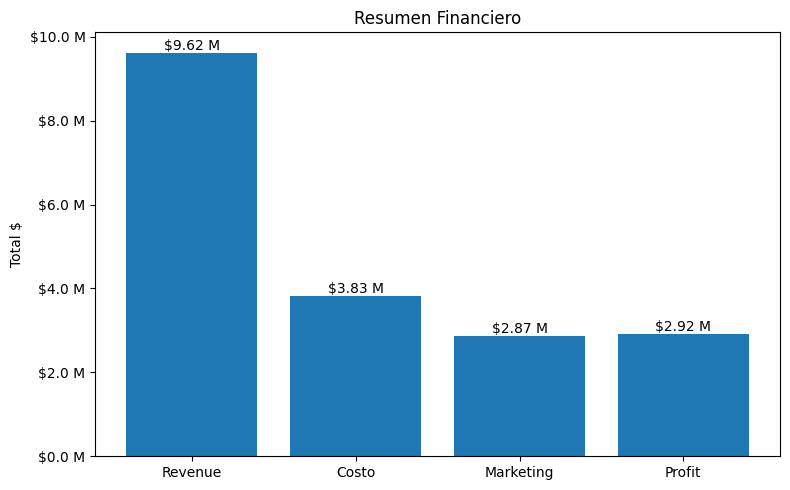

In [ ]:
# Visualización KPIs

from matplotlib.ticker import FuncFormatter

# Datos
metricas = ['Revenue', 'Costo', 'Marketing', 'Profit']
valores = [revenue, costo_total, marketing_total, profit]

# Función para mostrar millones
def millones(x, pos):
    return f'${x/1_000_000:.1f} M'

plt.figure(figsize=(8,5))

bars = plt.bar(metricas, valores)

plt.title('Resumen Financiero')
plt.ylabel('Total $')

# Cambiar formato del eje Y
plt.gca().yaxis.set_major_formatter(FuncFormatter(millones))

# Etiquetas sobre las barras
for bar in bars:
    altura = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        altura,
        f'${altura/1_000_000:.2f} M',
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()

In [ ]:
# Ticket promedio
ticket_promedio = orders['monto_total'].mean()
print(f'Ticket promedio por orden:{ticket_promedio:.2f}')

Ticket promedio por orden:385.88


In [ ]:
# Cantidad promedio
cantidad_promedio = orders['cantidad'].mean()
print(f'Cantidad promedio de productos por orden:{cantidad_promedio:.2f}')

Cantidad promedio de productos por orden:1.50


In [ ]:
# Producto más vendido
producto_mas_vendido = orders.groupby('nombre_producto')['cantidad'].sum().sort_values(ascending=False)
print(producto_mas_vendido)

nombre_producto
Vacuum-Pro-Black        6284.0
Blender-XL-Red          6279.0
Jacket-Winter-M         6256.0
Sneakers-Urban-42       6172.0
Laptop-Gaming-16GB      4198.0
Tablet-Standard-64GB    4153.0
Phone-Pro-128GB         4140.0
Desconocido               45.0
Name: cantidad, dtype: float64


In [ ]:
# Gasto por canal
gasto_por_canal = marketing.groupby('canal')['gasto'].sum().sort_values(ascending=False)
print(gasto_por_canal)

canal
social         918043.21
organic        913533.01
paid_search    863088.21
Desconocido    177179.10
Name: gasto, dtype: float64


---

## 🔹 Paso 3: Entender dónde se pierden los usuarios (funnel de conversión)

**🎯 Objetivo:** Analizar el comportamiento de los usuarios para identificar en qué etapa del proceso se pierden.


⚙️**Conexión a la base de datos**:  
Se ejecuta la línea de configuración para conectar con la base de datos y aplicar consultas SQL en la tabla **events**.

---

**📊 Parte 1: Construcción del funnel**
- ¿Cuántos usuarios llegan a cada etapa del funnel?  
- Se calcula el número de usuarios únicos por `nombre_evento`  
- Se ordenan los eventos según el flujo del usuario  

---

**📉 Parte 2: Análisis de conversión**
- Se calcula la tasa de conversión entre cada paso del funnel  
- Se identifica en qué etapa se pierde la mayor cantidad de usuarios  
- ¿Cuál es la tasa de conversión final?
---

In [ ]:
import pandas as pd
from sqlalchemy import create_engine

# Database connection
# Las credenciales de acceso a la base de datos fueron eliminadas
# por motivos de seguridad y privacidad.
# Las consultas SQL y sus resultados se conservan a continuación.

connection_string = 'postgresql://{}:{}@{}:{}/{}'.format(
    db_config['user'],
    db_config['pwd'],
    db_config['host'],
    db_config['port'],
    db_config['db']
)

engine = create_engine(connection_string, connect_args={'sslmode':'require'})

In [ ]:
# Explorar tabla events
# =========================
query_events = '''
SELECT *
FROM events;
'''
events = pd.read_sql(query_events, con=engine)
events['nombre_evento'].value_counts()

first_visit         29957
add_to_cart         24157
select_item         23887
begin_checkout      17971
add_payment_info    12018
purchase            12010
Name: nombre_evento, dtype: int64

In [ ]:
# PARTE 1: Totales del funnel
# ======================

query_totals = '''


WITH cte_first AS (
     SELECT DISTINCT id_usuario
     FROM events
     WHERE nombre_evento = 'first_visit'
     ),

    cte_select AS (
     SELECT DISTINCT id_usuario
     FROM events
     WHERE nombre_evento = 'select_item'
     ),

    cte_cart AS (
     SELECT DISTINCT id_usuario
     FROM events
     WHERE nombre_evento = 'add_to_cart'
     ),

    cte_checkout AS (
     SELECT DISTINCT id_usuario
     FROM events
     WHERE nombre_evento = 'begin_checkout'
     ),

    cte_payment AS (
     SELECT DISTINCT id_usuario
     FROM events
     WHERE nombre_evento = 'add_payment_info'
     ),

    cte_purchase AS (
     SELECT DISTINCT id_usuario
     FROM events
     WHERE nombre_evento = 'purchase'
     )
SELECT
    (SELECT COUNT(*) FROM cte_first) AS first_users,
    (SELECT COUNT(*) FROM cte_select) AS select_users,
    (SELECT COUNT(*) FROM cte_cart) AS cart_users,
    (SELECT COUNT(*) FROM cte_checkout) AS checkout_users,
    (SELECT COUNT(*) FROM cte_payment) AS payment_users,
    (SELECT COUNT(*) FROM cte_purchase) AS purchase_users
'''

totals = pd.read_sql(query_totals, con=engine)
totals

,first_users,select_users,cart_users,checkout_users,payment_users,purchase_users
0,7796,7582,7634,7208,6250,6240


In [ ]:
# PARTE 2: Conversiones
# ======================

query_conversion = '''

WITH cte_first AS (
    SELECT DISTINCT id_usuario
    FROM events
    WHERE nombre_evento = 'first_visit'
),

cte_select AS (
    SELECT DISTINCT id_usuario
    FROM events
    WHERE nombre_evento = 'select_item'
),

cte_cart AS (
    SELECT DISTINCT id_usuario
    FROM events
    WHERE nombre_evento = 'add_to_cart'
),

cte_checkout AS (
    SELECT DISTINCT id_usuario
    FROM events
    WHERE nombre_evento = 'begin_checkout'
),

cte_payment AS (
    SELECT DISTINCT id_usuario
    FROM events
    WHERE nombre_evento = 'add_payment_info'
),

cte_purchase AS (
    SELECT DISTINCT id_usuario
    FROM events
    WHERE nombre_evento = 'purchase'
)

SELECT

    ROUND(
        (SELECT COUNT(*) FROM cte_select) * 100.0 /
        NULLIF((SELECT COUNT(*) FROM cte_first),0),2
    ) AS conversion_first_to_select,

    ROUND(
        (SELECT COUNT(*) FROM cte_cart) * 100.0 /
        NULLIF((SELECT COUNT(*) FROM cte_select),0),2
    ) AS conversion_select_to_cart,

    ROUND(
        (SELECT COUNT(*) FROM cte_checkout) * 100.0 /
        NULLIF((SELECT COUNT(*) FROM cte_cart),0),2
    ) AS conversion_cart_to_checkout,

    ROUND(
        (SELECT COUNT(*) FROM cte_payment) * 100.0 /
        NULLIF((SELECT COUNT(*) FROM cte_checkout),0),2
    ) AS conversion_checkout_to_payment,

    ROUND(
        (SELECT COUNT(*) FROM cte_purchase) * 100.0 /
        NULLIF((SELECT COUNT(*) FROM cte_payment),0),2
    ) AS conversion_payment_to_purchase;
'''

conversion = pd.read_sql(query_conversion, con=engine)
conversion

,conversion_first_to_select,conversion_select_to_cart,conversion_cart_to_checkout,conversion_checkout_to_payment,conversion_payment_to_purchase
0,97.26,100.69,94.42,86.71,99.84


---

## 🔹 Paso 4: Evaluar si los usuarios regresan (retención por cohortes)

**🎯 Objetivo:** Analizar la retención de usuarios para entender si regresan después de registrarse.

**Tablas**

- `users`
- `user_activity`

---
1. Se identifica la cohorte de cada usuario según el **mes de registro**.


2. Se calcula la retención semanal: cuántos usuarios **se mantienen activos** en cada semana desde su registro.
   - `retenido_w1`: usuarios activos en la semana 1  
   - `retenido_w2`: usuarios activos en la semana 2  
   - `retenido_w3`: usuarios activos en la semana 3  


3. Se calcula el porcentaje de retención para cada semana, dividiendo los usuarios retenidos entre los clientes iniciales de la cohorte:  
   - `semana_1`: porcentaje de usuarios retenidos en la semana 1  
   - `semana_2`: porcentaje de usuarios retenidos en la semana 2  
   - `semana_3`: porcentaje de usuarios retenidos en la semana 3  

Se revisa que la columna de fecha esté en formato correcto (`DATE`).  
Se realiza la conversión usando: `CAST(fecha_registro AS DATE)`

In [ ]:
# Explorar tabla users
# =========================
query_users = '''
SELECT *
FROM users;
'''
users = pd.read_sql(query_users, con=engine)
users.head(3)

,id_usuario,fecha_registro,país,dispositivo,tipo_plan
0,user_0,2025-01-29,Mexico,mobile,free
1,user_1,2025-01-07,Mexico,mobile,free
2,user_2,2025-03-12,Argentina,mobile,free


In [ ]:
# Explorar tabla user_activity
# =========================
query_user_activity = '''
SELECT *
FROM user_activity
'''
user_activity = pd.read_sql(query_user_activity, con=engine)
user_activity.head(3)

,id_usuario,fecha_actividad,dias_despues_registro,activo
0,user_0,2025-02-05,7,0
1,user_0,2025-02-12,14,1
2,user_0,2025-02-19,21,1


In [ ]:
# Retención por cohortes
# ======================

query_cohort_retention_final = '''
WITH cohortes AS (

    SELECT
        u.id_usuario,
        DATE_TRUNC('month', CAST(u.fecha_registro AS DATE)) AS cohorte,
        ua.dias_despues_registro,
        ua.activo
    FROM users u
    LEFT JOIN user_activity ua
        ON u.id_usuario = ua.id_usuario

)

SELECT

    cohorte,

    COUNT(DISTINCT id_usuario) AS usuarios_iniciales,

    COUNT(DISTINCT CASE
        WHEN dias_despues_registro BETWEEN 1 AND 7
        AND activo = 1
        THEN id_usuario
    END) AS retenido_w1,

    COUNT(DISTINCT CASE
        WHEN dias_despues_registro BETWEEN 8 AND 14
        AND activo = 1
        THEN id_usuario
    END) AS retenido_w2,

    COUNT(DISTINCT CASE
        WHEN dias_despues_registro BETWEEN 15 AND 21
        AND activo = 1
        THEN id_usuario
    END) AS retenido_w3,

    ROUND(
        COUNT(DISTINCT CASE
            WHEN dias_despues_registro BETWEEN 1 AND 7
            AND activo = 1
            THEN id_usuario
        END) * 100.0 /
        COUNT(DISTINCT id_usuario),
        2
    ) AS semana_1,

    ROUND(
        COUNT(DISTINCT CASE
            WHEN dias_despues_registro BETWEEN 8 AND 14
            AND activo = 1
            THEN id_usuario
        END) * 100.0 /
        COUNT(DISTINCT id_usuario),
        2
    ) AS semana_2,

    ROUND(
        COUNT(DISTINCT CASE
            WHEN dias_despues_registro BETWEEN 15 AND 21
            AND activo = 1
            THEN id_usuario
        END) * 100.0 /
        COUNT(DISTINCT id_usuario),
        2
    ) AS semana_3

FROM cohortes

GROUP BY cohorte

ORDER BY cohorte DESC;
'''

# Ejecutar la consulta
cohorte_final = pd.read_sql(query_cohort_retention_final, con=engine)
cohorte_final

,cohorte,usuarios_iniciales,retenido_w1,retenido_w2,retenido_w3,semana_1,semana_2,semana_3
0,2025-05-01 00:00:00+00:00,1687,695,676,706,41.20,40.07,41.85
1,2025-04-01 00:00:00+00:00,1606,680,697,663,42.34,43.40,41.28
2,2025-03-01 00:00:00+00:00,1636,677,705,690,41.38,43.09,42.18
3,2025-02-01 00:00:00+00:00,1444,611,609,635,42.31,42.17,43.98
4,2025-01-01 00:00:00+00:00,1627,697,668,656,42.84,41.06,40.32


---

## 🔹 Paso 5: Validar si los cambios generan impacto (test estadístico)

🎯 **Objetivo:** Evaluar si la modificación en la UI del checkout impacta la **tasa de conversión de compra**.

---

1. **Analizar el dataset** `experiment_checkout_ui.csv` para identificar la métrica principal **conversion**.
   - La métrica **conversion** es 1 si el usuario completó la compra, 0 si no.    
2. **Plantear la hipótesis estadística**     
3. **Aplicar el test estadístico adecuado**
4. **Interpretar el resultado**  

---
Hipótesis estadística
   - **H₀ (Hipótesis nula):** La tasa de conversión antes y después de la modificación en la UI del checkout es igual. Cualquier diferencia se debe al azar.
   - **H₁ (Hipótesis alternativa):** La tasa de conversión antes y después de la modificación de la UI del checkout es diferente. La diferencia observada no se explica únicamente por el azar.

**Test estadístico:** prueba Z  
**Nivel de significancia alpha:** 0.05


In [ ]:
# tu código aquí
checkout = pd.read_csv('https://practicum-content.s3.amazonaws.com/datasets/experiment_checkout_ui.csv')

In [ ]:
#contar numero de exitos y numero totales de registro
conversiones = checkout.groupby('variante')['convirtio'].sum()
totales = checkout.groupby('variante')['convirtio'].count()

#pasar valores a formato lista
exitos = [conversiones['control'],conversiones['tratamiento']]
observaciones = [totales['control'],totales['tratamiento']]

#Aplicar prueba y visualizar resultados

z_stat,p_value = proportions_ztest(exitos,observaciones)
print(f'estadístico z:{z_stat}')
print(f'valor p:{p_value}')

#Interpretar resultados

alpha = 0.05 #umbral de significancia
if p_value < alpha:
    print('Rechazamos la hipótesis nula:hay evidencia de una diferencia')
else:
    print('No rechazamos la hipótesis nula:no hay suficeinte evidencia de una diferencia')

estadístico z:-0.8132782986429474
valor p:0.41605851639119995
No rechazamos la hipótesis nula: no hay suficeinte evidencia de una diferencia


In [ ]:
#Calcular porcentajes de conversión

tasa_control = exitos[0]/observaciones[0]
tasa_tratamiento = exitos[1]/observaciones[1]

#Interpretación

if tasa_control > tasa_tratamiento:
    print(f'\nLa página control tiene mayor tasa de conversión({tasa_control-tasa_tratamiento:.2%}).')
elif tasa_tratamiento > tasa_control:
    print(f'\nLa página tratamiento tiene mayor tasa de conversión({tasa_tratamiento-tasa_control:.2%}).')
else:
    print('Ambas páginas tienen la misma tasa de conversión')



La página tratamiento tiene mayor tasa de conversión(0.60%).


---

## 🔹 Paso 6: Comunicar los resultados (Dashboard en BI)

🎯 **Objetivo**:  
Crear un dashboard que muestre de manera clara y visual los resultados del análisis de ventas, costos, marketing y conversión.

Se usarán los CSVs limpios del Paso 1:

- `orders_clean.csv`  
- `catalog_clean.csv`  
- `marketing_clean.csv`

---

1️⃣ Preparación de los datos
1. Cargar los CSVs en Power BI o Tableau.
2. Revisar relaciones:
   - `orders.nombre_producto` → `catalog.nombre_producto`
   - `orders.fecha_pedido` → tabla de fechas (crear calendario para análisis temporal)
   - `orders.fecha_pedido` → `dim_fecha.date`
3. Crear columnas calculadas necesarias
4. Crear tabla de fechas para poder calcular comparaciones YTD, YoY o períodos anteriores (`Previous Year`, `Previous Month`).

---

2️⃣ Dashboard 1: Overview Ejecutivo
**KPIs principales a mostrar:**
- Revenue total
- Profit total
- Ticket promedio


---

 3️⃣ Dashboard 2: Detalle / Drill-through  
**Objetivo:** Permitir explorar los datos desde el KPI general hasta cada orden o producto.


---